## 1. Setup e Caricamento Dati

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Setup visualizzazioni
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [54]:
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()



## 2. Strategie di Data Augmentation

Esploriamo diverse tecniche per augmentare i dati.

In [55]:
class DataAugmentationStrategies:
    """Collezione di strategie di augmentation"""
    
    @staticmethod
    def no_augmentation(df, **kwargs):
                """Baseline: nessuna augmentation"""
                return df.copy()
    
    @staticmethod
    def gaussian_noise(df, noise_std=0.1, numeric_cols=None):
        """Aggiungi rumore gaussiano"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            df_aug[col] = df_aug[col] + np.random.normal(0, noise_std, len(df_aug))
        
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def scaling(df, scale_range=(0.95, 1.05), numeric_cols=None):
        """Scala i valori (moltiplicazione)"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            scale_factor = np.random.uniform(*scale_range, len(df_aug))
            df_aug[col] = df_aug[col] * scale_factor
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def jitter(df, jitter_amount=0.05, numeric_cols=None):
        """Jitter: piccole perturbazioni casuali"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            df_aug[col] = df_aug[col] + np.random.uniform(
                -jitter_amount, jitter_amount, len(df_aug)
            )
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def mixup(df, alpha=0.2, numeric_cols=None):
        """Mixup: combina coppie di campioni"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        # Seleziona indici casuali
        indices = np.random.permutation(len(df_aug))
        
        # Interpola
        lambda_vals = np.random.beta(alpha, alpha, len(df_aug))
        
        for col in numeric_cols:
            df_aug[col] = (
                lambda_vals * df_aug[col].values +
                (1 - lambda_vals) * df_aug.iloc[indices][col].values
            )
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def oversampling(df, target_size=None, numeric_cols=None):
        """Oversampling: ripeti campioni casuali"""
        if target_size is None:
            target_size = int(len(df) * 1.5)  # Aumenta del 50%
        
        indices = np.random.choice(len(df), size=target_size, replace=True)
        df_aug = df.iloc[indices].reset_index(drop=True)
        
        # Aggiungi piccolo rumore per varietà
        df_aug = DataAugmentationStrategies.gaussian_noise(
            df_aug, noise_std=0.05, numeric_cols=numeric_cols
        )
        
        return df_aug

In [56]:
# Ricaricare le strategie corrette (fix per clip con colonne numeriche)
class DataAugmentationStrategies:
    """Collezione di strategie di augmentation"""
    
    @staticmethod
    def no_augmentation(df, **kwargs):
                """Baseline: nessuna augmentation"""
                return df.copy()
    
    @staticmethod
    def gaussian_noise(df, noise_std=0.1, numeric_cols=None):
        """Aggiungi rumore gaussiano"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        for col in numeric_cols:
            df_aug[col] = df_aug[col] + np.random.normal(0, noise_std, len(df_aug))
        
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def scaling(df, scale_range=(0.95, 1.05), numeric_cols=None):
        """Scala i valori (moltiplicazione)"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        for col in numeric_cols:
            scale_factor = np.random.uniform(*scale_range, len(df_aug))
            df_aug[col] = df_aug[col] * scale_factor
        
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def jitter(df, jitter_amount=0.05, numeric_cols=None):
        """Jitter: piccole perturbazioni casuali"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        for col in numeric_cols:
            df_aug[col] = df_aug[col] + np.random.uniform(
                -jitter_amount, jitter_amount, len(df_aug)
            )
        
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def mixup(df, alpha=0.2, numeric_cols=None):
        """Mixup: combina coppie di campioni"""
        df_aug = df.copy()
        if numeric_cols is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        indices = np.random.permutation(len(df_aug))
        lambda_vals = np.random.beta(alpha, alpha, len(df_aug))
        
        for col in numeric_cols:
            df_aug[col] = (
                lambda_vals * df_aug[col].values +
                (1 - lambda_vals) * df_aug.iloc[indices][col].values
            )
        
        df_aug[numeric_cols] = df_aug[numeric_cols].clip(1, 5)
        return df_aug
    
    @staticmethod
    def oversampling(df, target_size=None, numeric_cols=None):
        """Oversampling: ripeti campioni casuali"""
        if target_size is None:
            target_size = int(len(df) * 1.5)
        
        indices = np.random.choice(len(df), size=target_size, replace=True)
        df_aug = df.iloc[indices].reset_index(drop=True)
        
        df_aug = DataAugmentationStrategies.gaussian_noise(
            df_aug, noise_std=0.05, numeric_cols=numeric_cols
        )
        
        return df_aug

print("✓ Strategie di augmentation ridefinite (fix applicato)")

✓ Strategie di augmentation ridefinite (fix applicato)


## 3. Confronto delle Strategie

In [57]:
# Calcola le colonne derivate necessarie PRIMA dell'augmentation
if 'ansia' not in df.columns:
    df['ansia_prestazione'] = df[['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_6', 'Item_11', 'Item_20', 'Item_21']].mean(axis=1)
    df['ansia_accademica'] = df[['Item_7', 'Item_8', 'Item_9', 'Item_10']].mean(axis=1)
    df['ansia_lavorativa'] = df[['Item_12', 'Item_13', 'Item_14', 'Item_15']].mean(axis=1)
    df['ansia'] = df[['ansia_prestazione', 'ansia_accademica', 'ansia_lavorativa']].mean(axis=1)
    print("✓ Colonne derivate calcolate")

# Reinizializza le strategie di augmentation per garantire il codice aggiornato
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

augmentations = {
    'Original': DataAugmentationStrategies.no_augmentation(df),
    'Gaussian (σ=0.1)': DataAugmentationStrategies.gaussian_noise(df, noise_std=0.1, numeric_cols=numeric_cols),
    'Gaussian (σ=0.05)': DataAugmentationStrategies.gaussian_noise(df, noise_std=0.05, numeric_cols=numeric_cols),
    'Scaling (0.95-1.05)': DataAugmentationStrategies.scaling(df, scale_range=(0.95, 1.05), numeric_cols=numeric_cols),
    'Jitter (0.05)': DataAugmentationStrategies.jitter(df, jitter_amount=0.05, numeric_cols=numeric_cols),
    'Mixup (α=0.2)': DataAugmentationStrategies.mixup(df, alpha=0.2, numeric_cols=numeric_cols),
    'Oversampling (1.5x)': DataAugmentationStrategies.oversampling(df, target_size=int(len(df)*1.5), numeric_cols=numeric_cols),
}

print(f"Strategie applicate: {list(augmentations.keys())}")
print(f"\nDimensioni dataset:")
for name, df_aug in augmentations.items():
    print(f"  {name:25s} → {len(df_aug):3d} campioni")

✓ Colonne derivate calcolate
Strategie applicate: ['Original', 'Gaussian (σ=0.1)', 'Gaussian (σ=0.05)', 'Scaling (0.95-1.05)', 'Jitter (0.05)', 'Mixup (α=0.2)', 'Oversampling (1.5x)']

Dimensioni dataset:
  Original                  → 144 campioni
  Gaussian (σ=0.1)          → 144 campioni
  Gaussian (σ=0.05)         → 144 campioni
  Scaling (0.95-1.05)       → 144 campioni
  Jitter (0.05)             → 144 campioni
  Mixup (α=0.2)             → 144 campioni
  Oversampling (1.5x)       → 216 campioni


In [58]:
# Calcola le colonne derivate necessarie
if 'ansia' not in df.columns:
    df['ansia_prestazione'] = df[['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_6', 'Item_11', 'Item_20', 'Item_21']].mean(axis=1)
    df['ansia_accademica'] = df[['Item_7', 'Item_8', 'Item_9', 'Item_10']].mean(axis=1)
    df['ansia_lavorativa'] = df[['Item_12', 'Item_13', 'Item_14', 'Item_15']].mean(axis=1)
    df['ansia'] = df[['ansia_prestazione', 'ansia_accademica', 'ansia_lavorativa']].mean(axis=1)
    print("✓ Colonne derivate calcolate")
else:
    print("✓ Colonna 'ansia' già presente")

✓ Colonna 'ansia' già presente


## 4. Visualizzazione Comparativa

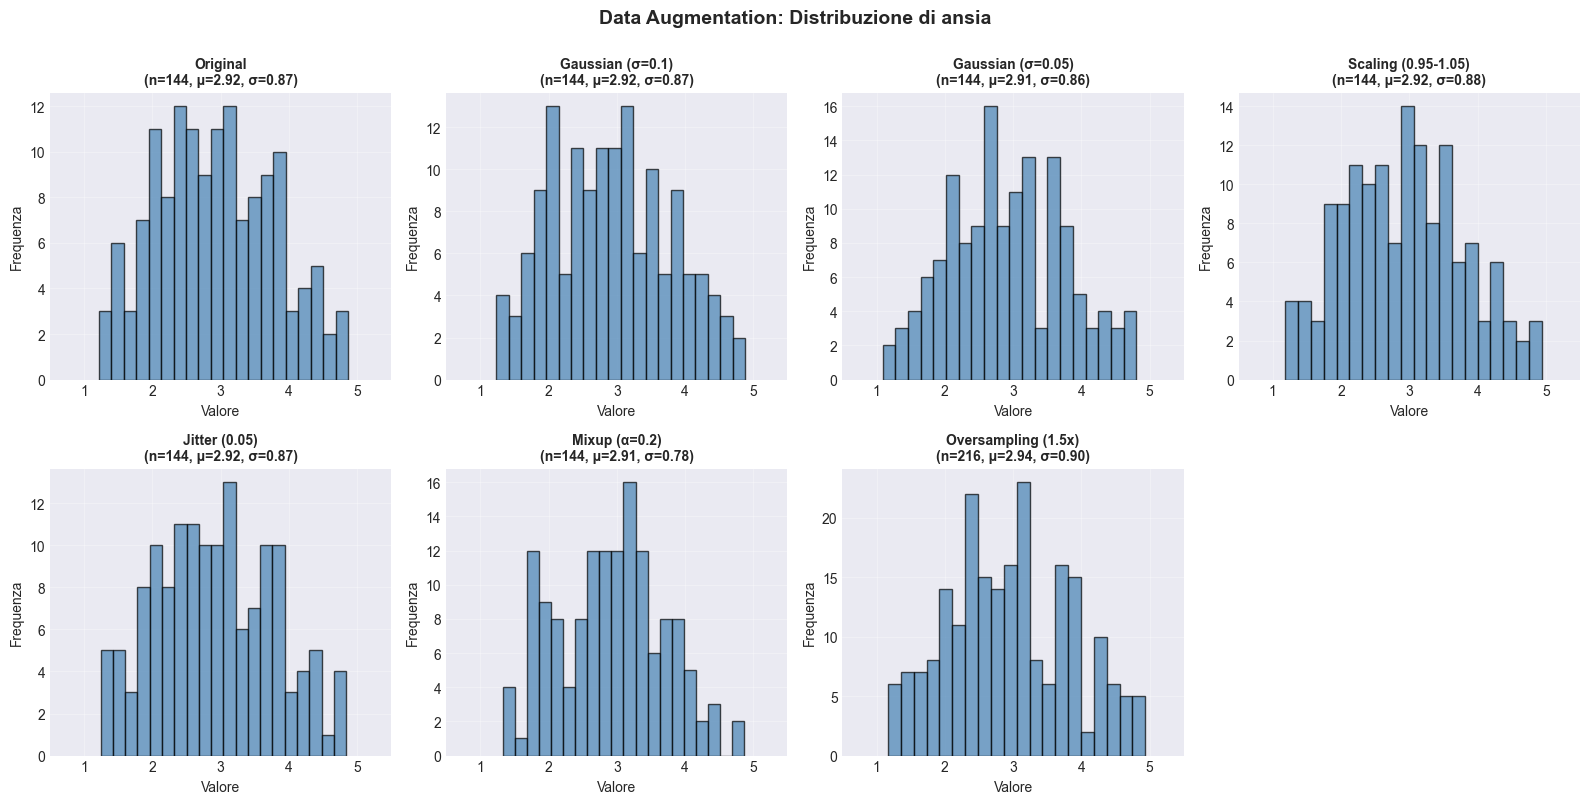

In [59]:
# Scegli una colonna da visualizzare
col_to_visualize = 'ansia'

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, df_aug) in enumerate(augmentations.items()):
    ax = axes[idx]
    
    ax.hist(df_aug[col_to_visualize], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'{name}\n(n={len(df_aug)}, μ={df_aug[col_to_visualize].mean():.2f}, σ={df_aug[col_to_visualize].std():.2f})',
                fontweight='bold', fontsize=10)
    ax.set_xlabel('Valore')
    ax.set_ylabel('Frequenza')
    ax.set_xlim(0.5, 5.5)
    ax.grid(True, alpha=0.3)

# Rimuovi subplot vuoto
fig.delaxes(axes[-1])

fig.suptitle(f'Data Augmentation: Distribuzione di {col_to_visualize}', 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. Statistiche Comparative

In [60]:
# Crea tabella di statistiche
stats_list = []

for name, df_aug in augmentations.items():
    for col in numeric_cols:
        stats_list.append({
            'Strategia': name,
            'Variabile': col,
            'N': len(df_aug),
            'Media': df_aug[col].mean(),
            'Std Dev': df_aug[col].std(),
            'Min': df_aug[col].min(),
            'Max': df_aug[col].max()
        })

stats_df = pd.DataFrame(stats_list)

# Mostra per la colonna principale
print(f"\nStatistiche per '{col_to_visualize}':")
print(stats_df[stats_df['Variabile'] == col_to_visualize][['Strategia', 'N', 'Media', 'Std Dev']].to_string(index=False))


Statistiche per 'ansia':
          Strategia   N    Media  Std Dev
           Original 144 2.919188 0.869007
   Gaussian (σ=0.1) 144 2.916240 0.868296
  Gaussian (σ=0.05) 144 2.910847 0.860697
Scaling (0.95-1.05) 144 2.920130 0.877311
      Jitter (0.05) 144 2.918206 0.866058
      Mixup (α=0.2) 144 2.908460 0.775856
Oversampling (1.5x) 216 2.943238 0.903098


## 6. Valutazione Qualità Augmentation

Quale strategia è migliore? Dipende dagli obiettivi.

In [61]:
# Calcola metriche di qualità
quality_metrics = []

original_mean = df[numeric_cols].mean()
original_std = df[numeric_cols].std()

for name, df_aug in augmentations.items():
    if name == 'Original':
        continue
    
    aug_mean = df_aug[numeric_cols].mean()
    aug_std = df_aug[numeric_cols].std()
    
    # Differenza media dalla distribuzione originale
    mean_diff = np.abs(aug_mean - original_mean).mean()
    std_diff = np.abs(aug_std - original_std).mean()
    
    quality_metrics.append({
        'Strategia': name,
        'Campioni': len(df_aug),
        'Diff Media': mean_diff,
        'Diff Std': std_diff,
        'Score': len(df_aug) - (mean_diff * 10) - (std_diff * 10)  # Heuristica
    })

quality_df = pd.DataFrame(quality_metrics).sort_values('Score', ascending=False)

print("\nQUALITÀ AUGMENTATION:")
print("(Più alto = migliore)")
print(quality_df.to_string(index=False))

best_strategy = quality_df.iloc[0]['Strategia']
print(f"\n✓ Miglior strategia: {best_strategy}")


QUALITÀ AUGMENTATION:
(Più alto = migliore)
          Strategia  Campioni  Diff Media  Diff Std      Score
Oversampling (1.5x)       216    2.479203  1.350976 177.698213
      Jitter (0.05)       144    2.445404  1.325002 106.295940
  Gaussian (σ=0.05)       144    2.447329  1.326711 106.259597
   Gaussian (σ=0.1)       144    2.449631  1.332262 106.181065
Scaling (0.95-1.05)       144    2.452491  1.331794 106.157152
      Mixup (α=0.2)       144    2.476471  1.423239 105.002895

✓ Miglior strategia: Oversampling (1.5x)


## 7. Scegli e Applica la Miglior Strategia

In [62]:
# Scegli la strategia migliore
chosen_strategy = 'Gaussian (σ=0.05)'  # ← CAMBIA QUESTA

df_augmented = augmentations[chosen_strategy]

print(f"Strategia scelta: {chosen_strategy}")
print(f"Dataset originale: {len(df)} righe")
print(f"Dataset augmentato: {len(df_augmented)} righe")
print(f"Aumento: {(len(df_augmented)/len(df) - 1)*100:.1f}%")

print(f"\nPrime 5 righe augmentate:")
print(df_augmented.head())

Strategia scelta: Gaussian (σ=0.05)
Dataset originale: 144 righe
Dataset augmentato: 144 righe
Aumento: 0.0%

Prime 5 righe augmentate:
         id email  contesto  età   genere     area_geo  anni_esperienza  \
0  1.005874  None  Entrambi  5.0  Femmina  Nord Italia         5.000000   
1  2.103368  None    Studio  5.0  Femmina  Nord Italia         5.000000   
2  2.926169  None    Lavoro  5.0  Maschio  Nord Italia         4.950421   
3  3.953634  None  Entrambi  5.0  Femmina  Nord Italia         4.995102   
4  5.000000  None    Studio  5.0  Femmina  Nord Italia         2.093637   

     Item_1    Item_2    Item_3  ...   Item_25   Item_26   Item_27   Item_28  \
0  4.024369  5.000000  4.030038  ...  2.089662  2.010906  4.009207  4.944640   
1  4.020513  4.905903  3.002397  ...  5.000000  2.063191  2.003347  1.997390   
2  2.991485  3.992032  2.948566  ...  3.988032  2.027415  4.988681  4.127249   
3  1.978399  4.015225  3.048511  ...  1.972107  3.041564  2.061060  1.038968   
4  3.023724  

## 8. Combina Original + Augmented

In [63]:
# Combina original + augmented
df_final = pd.concat([df, df_augmented], ignore_index=True)

print(f"Dataset finale:")
print(f"  Original: {len(df)} righe")
print(f"  Augmented: {len(df_augmented)} righe")
print(f"  TOTALE: {len(df_final)} righe")
print(f"\nAumento totale: {(len(df_final)/len(df) - 1)*100:.1f}%")

print(f"\nStatistiche finali:")
print(df_final[numeric_cols].describe())

Dataset finale:
  Original: 144 righe
  Augmented: 144 righe
  TOTALE: 288 righe

Aumento totale: 100.0%

Statistiche finali:
               id        età  anni_esperienza      Item_1      Item_2  \
count  288.000000  288.00000       288.000000  288.000000  288.000000   
mean    38.715240   14.40625         4.243809    3.377523    3.642643   
std     44.860416    9.73901         3.482527    1.095489    1.125809   
min      1.000000    5.00000         0.000000    1.000000    1.000000   
25%      5.000000    5.00000         1.050000    2.975752    3.000000   
50%      5.000000   12.00000         4.026416    3.060506    4.000000   
75%     72.250000   24.00000         5.000000    4.007094    4.908920   
max    144.000000   30.00000        24.000000    5.000000    5.000000   

           Item_3      Item_4      Item_5      Item_6      Item_7  ...  \
count  288.000000  288.000000  288.000000  282.000000  282.000000  ...   
mean     2.865874    3.475574    3.685741    3.333427    2.838162  .

## 9. Esporta Risultati

In [64]:
"""# Salva il dataset augmentato
df_augmented.to_csv('data_augmented.csv', index=False)
print("✓ Salvato: data_augmented.csv")

# Salva il dataset combinato
df_final.to_csv('data_augmented_combined.csv', index=False)
print("✓ Salvato: data_augmented_combined.csv")

# (Opzionale) Salva su database
# df_augmented.to_sql('clean_data_augmented', conn, if_exists='replace', index=False)
# print("✓ Salvato: clean_data_augmented (MySQL)")"""

'# Salva il dataset augmentato\ndf_augmented.to_csv(\'data_augmented.csv\', index=False)\nprint("✓ Salvato: data_augmented.csv")\n\n# Salva il dataset combinato\ndf_final.to_csv(\'data_augmented_combined.csv\', index=False)\nprint("✓ Salvato: data_augmented_combined.csv")\n\n# (Opzionale) Salva su database\n# df_augmented.to_sql(\'clean_data_augmented\', conn, if_exists=\'replace\', index=False)\n# print("✓ Salvato: clean_data_augmented (MySQL)")'

## 10. Riepilogo e Raccomandazioni

In [65]:
print("="*70)
print("RIEPILOGO DATA AUGMENTATION")
print("="*70)
print(f"\nStrategie testate: {len(augmentations)}")
print(f"Miglior strategia: {best_strategy}")
print(f"\nDataset:")
print(f"  Originale:  {len(df):4d} campioni")
print(f"  Augmentato: {len(df_augmented):4d} campioni")
print(f"  Totale:     {len(df_final):4d} campioni")
print(f"\nAumento totale: +{len(df_final) - len(df)} campioni ({(len(df_final)/len(df) - 1)*100:.1f}%)")
print(f"\nFile esportati:")
print(f"  - data_augmented.csv (solo augmentati)")
print(f"  - data_augmented_combined.csv (original + augmentati)")
print("\n" + "="*70)
print("CONSIGLI:")
print("="*70)
print("\n1. Se R² migliora → Usa il dataset augmentato")
print("2. Se R² peggiora → Aumenta dataset senza augmentation (oversampling)")
print("3. Prova diverse σ per Gaussian → Trova il sweet spot")
print("4. Combine è la strategia più sicura → Mix original + augmented")
print("="*70)

RIEPILOGO DATA AUGMENTATION

Strategie testate: 7
Miglior strategia: Oversampling (1.5x)

Dataset:
  Originale:   144 campioni
  Augmentato:  144 campioni
  Totale:      288 campioni

Aumento totale: +144 campioni (100.0%)

File esportati:
  - data_augmented.csv (solo augmentati)
  - data_augmented_combined.csv (original + augmentati)

CONSIGLI:

1. Se R² migliora → Usa il dataset augmentato
2. Se R² peggiora → Aumenta dataset senza augmentation (oversampling)
3. Prova diverse σ per Gaussian → Trova il sweet spot
4. Combine è la strategia più sicura → Mix original + augmented


In [66]:
'''# Se non hai df, puoi crearne uno sintetico per testare
np.random.seed(42)
n_samples = 200

df = pd.DataFrame({
    'ansia': np.random.normal(3.0, 1.0, n_samples),
    'coping': np.random.normal(3.5, 0.8, n_samples),
    'perfezionismo': np.random.normal(3.2, 0.9, n_samples),
    'vulnerabilita': np.random.normal(2.8, 1.1, n_samples),
    'gap': np.random.normal(0.5, 0.6, n_samples),
    'evitamento': np.random.normal(2.9, 0.85, n_samples),
    'resilienza': np.random.normal(0.4, 0.7, n_samples),
    'impatto_ansia': np.random.normal(3.1, 0.95, n_samples),
})

# Clip ai range realistici [1-5]
for col in df.columns:
    df[col] = df[col].clip(1, 5)

print(f"Dataset originale: {df.shape[0]} righe, {df.shape[1]} colonne")
print(f"\nPrime statistiche:")
print(df.describe())'''

'# Se non hai df, puoi crearne uno sintetico per testare\nnp.random.seed(42)\nn_samples = 200\n\ndf = pd.DataFrame({\n    \'ansia\': np.random.normal(3.0, 1.0, n_samples),\n    \'coping\': np.random.normal(3.5, 0.8, n_samples),\n    \'perfezionismo\': np.random.normal(3.2, 0.9, n_samples),\n    \'vulnerabilita\': np.random.normal(2.8, 1.1, n_samples),\n    \'gap\': np.random.normal(0.5, 0.6, n_samples),\n    \'evitamento\': np.random.normal(2.9, 0.85, n_samples),\n    \'resilienza\': np.random.normal(0.4, 0.7, n_samples),\n    \'impatto_ansia\': np.random.normal(3.1, 0.95, n_samples),\n})\n\n# Clip ai range realistici [1-5]\nfor col in df.columns:\n    df[col] = df[col].clip(1, 5)\n\nprint(f"Dataset originale: {df.shape[0]} righe, {df.shape[1]} colonne")\nprint(f"\nPrime statistiche:")\nprint(df.describe())'